# Import Library

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

# Data Loading

In [14]:
df = pd.read_csv("/kaggle/input/competitions/insurance-premium-prediction-cpe-232-data-models/train.csv")
test = pd.read_csv("/kaggle/input/competitions/insurance-premium-prediction-cpe-232-data-models/test.csv")
SUBMIT_PATH = "submission.csv"

# EDA

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          30395 non-null  float64
 1   education                 30263 non-null  object 
 2   self_employed             29377 non-null  object 
 3   income_annum              29865 non-null  float64
 4   loan_amount               29082 non-null  float64
 5   loan_term                 30103 non-null  float64
 6   cibil_score               29230 non-null  float64
 7   residential_assets_value  29381 non-null  float64
 8   commercial_assets_value   29903 non-null  float64
 9   luxury_assets_value       30166 non-null  float64
 10  bank_asset_value          30082 non-null  float64
 11  loan_status               32000 non-null  int64  
dtypes: float64(9), int64(1), object(2)
memory usage: 2.9+ MB


In [27]:
df.isnull().sum()

no_of_dependents            1605
education                   1737
self_employed               2623
income_annum                2135
loan_amount                 2918
loan_term                   1897
cibil_score                 2770
residential_assets_value    2619
commercial_assets_value     2097
luxury_assets_value         1834
bank_asset_value            1918
loan_status                    0
dtype: int64

In [29]:
df.describe().round(2)

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,30395.00,29865.00,29082.00,30103.00,29230.00,29381.00,29903.00,30166.00,30082.00,32000.00
mean,1.95,3523465.89,12851018.58,12.37,661.73,3956637.73,6212830.13,11195238.62,4702795.46,0.54
std,1.63,2920311.31,9177296.64,5.44,173.09,5339316.22,5490717.20,8793568.27,3770260.76,0.50
min,0.00,0.00,0.00,0.00,223.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,830284.00,5416666.00,9.00,529.00,0.00,1880555.00,4067125.25,1596127.25,0.00
50%,2.00,2961480.00,11746169.00,13.00,663.50,1812942.00,4531977.00,9802424.50,3998887.50,1.00
75%,3.00,5827615.00,18701166.00,17.00,811.00,5528413.00,9059979.50,16711702.75,7027443.75,1.00
max,5.00,11369423.00,46044308.00,22.00,1011.00,34562020.00,24041102.00,46505087.00,17479340.00,1.00


In [30]:
print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
1    54.46875
0    45.53125
Name: proportion, dtype: float64


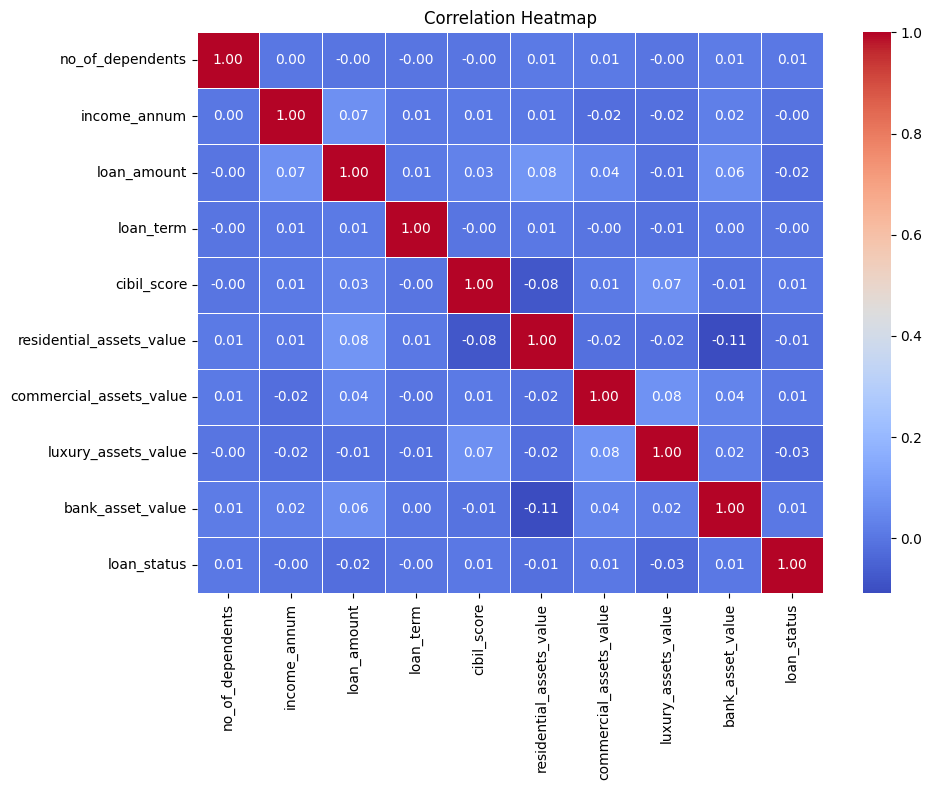

In [34]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Data Preprocessing

In [15]:
df = df.drop(columns=['id'])

X = df.drop(columns=['loan_status'])
y = df['loan_status']

In [16]:
categorical_cols = ['education', 'self_employed']
numeric_cols = [col for col in X.columns if col not in categorical_cols]

In [17]:
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_transformer, categorical_cols),
        ('num', num_transformer, numeric_cols)
    ],
    remainder='drop'
)

# Model Training

In [48]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=300,             
        learning_rate=0.05,      
        max_depth=4,              
        l2_regularization=0.1,   
        min_samples_leaf=20,     
        random_state=42
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['education',
                                                   'self_employed']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value'])])),
                ('classifier',
                 HistGradientBoostingClassifier(l2_regularization=0.1,
                                                learning_rate=0.05, max_depth=4,
                                                max_iter=300,
                                                min_samples_leaf=50,
                                                random_state=42))])

# Validation

In [50]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.00      0.01      2914
           1       0.55      1.00      0.71      3486

    accuracy                           0.55      6400
   macro avg       0.60      0.50      0.36      6400
weighted avg       0.59      0.55      0.39      6400



# Test data prediction

In [51]:
y_test = model.predict(test)
y_test

array([1, 1, 1, ..., 1, 1, 1])

In [52]:
submission = pd.DataFrame({
    "id": test["id"],
    "loan_status": y_test,        
})

In [53]:
submission['loan_status'].value_counts()

loan_status
1    7968
0      32
Name: count, dtype: int64

In [54]:
submission.to_csv(SUBMIT_PATH, index=False)